# 03 — Topic Modeling

This notebook applies topic modeling to the processed arXiv subset.

Topic modeling is an optional experiment in the project proposal, but it is useful for discovering hidden research themes and comparing them with knowledge graph structures.

## Goals

- Load processed documents.
- Prepare tokenized corpus.
- Train an LDA topic model.
- Inspect topic-word distributions.
- Save topic results for the final report.

In [14]:
from pathlib import Path
import sys

current = Path.cwd().resolve()

for candidate in [current, *current.parents]:
    if (candidate / "src").exists() and (candidate / "config.yaml").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find project root")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

from src.utils.common import (
    display_basic_frame_info,
    load_or_create_processed_documents,
    parse_token_column,
    save_json,
    save_table,
    setup_notebook,
)

CONFIG, PATHS = setup_notebook()

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform
Config: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\config.yaml
Raw data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\raw
Processed data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed
Graphs: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\graphs
Reports: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports
Figures: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports\figures


## Load processed documents

In [16]:
df = load_or_create_processed_documents(CONFIG, PATHS)

display_basic_frame_info(df, "Processed documents")

Loading processed documents from: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed\processed_documents.csv
Processed documents shape: (5000, 9)
Processed documents columns: ['doc_id', 'title', 'abstract', 'authors', 'categories', 'date', 'text', 'cleaned_text', 'tokens']


,doc_id,title,abstract,authors,categories,date,text,cleaned_text,tokens
0,1804.05499,Community Member Retrieval on Social Media usi...,This paper addresses the problem of communit...,"['Aaron Jaech', 'Shobhit Hathi', 'Mari Ostendo...",['cs.CL'],2018-04-17,Community Member Retrieval on Social Media usi...,community member retrieval social medium textu...,community member retrieval social medium textu...
1,2310.12815,Formalizing and Benchmarking Prompt Injection ...,A prompt injection attack aims to inject malic...,"['Yupei Liu', 'Yuqi Jia', 'Runpeng Geng', 'Jin...","['cs.CR', 'cs.AI', 'cs.CL', 'cs.LG']",2025-11-13,Formalizing and Benchmarking Prompt Injection ...,formalizing benchmarke prompt injection attack...,formalizing benchmarke prompt injection attack...
2,2303.12728,LocalEyenet: Deep Attention framework for Loca...,Development of human machine interface has b...,"['Somsukla Maiti', 'Akshansh Gupta']","['cs.CV', 'cs.LG']",2023-03-23,LocalEyenet: Deep Attention framework for Loca...,localeyenet deep attention framework localizat...,localeyenet deep attention framework localizat...
3,2012.12469,Augmenting Policy Learning with Routines Disco...,Humans can abstract prior knowledge from ver...,"['Zelin Zhao', 'Chuang Gan', 'Jiajun Wu', 'Xia...","['cs.LG', 'cs.AI', 'cs.SC']",2021-05-04,Augmenting Policy Learning with Routines Disco...,augment policy learning routine discover singl...,augment policy learning routine discover singl...
4,2601.10421,Are Language Models Models?,"Futrell and Mahowald claim LMs ""serve as model...",['Philip Resnik'],"['cs.CL', 'cs.AI']",2026-01-16,Are Language Models Models?. Futrell and Mahow...,language model model futrell mahowald claim se...,language model model futrell mahowald claim se...


## Prepare tokenized corpus

In [17]:
tokenized_docs = [parse_token_column(value) for value in df["tokens"]]
tokenized_docs = [tokens for tokens in tokenized_docs if tokens]

print("Documents in processed file:", len(df))
print("Documents with non-empty tokens:", len(tokenized_docs))

if tokenized_docs:
    print("Example tokens:", tokenized_docs[0][:25])
else:
    raise ValueError("No non-empty tokenized documents found.")

Documents in processed file: 5000
Documents with non-empty tokens: 5000
Example tokens: ['community', 'member', 'retrieval', 'social', 'medium', 'textual', 'information', 'paper', 'address', 'problem', 'community', 'membership', 'detection', 'text', 'feature', 'scenario', 'small', 'number', 'positive', 'label', 'example', 'define', 'community', 'solution', 'introduce']


## Configure topic modeling

In [18]:
topic_cfg = CONFIG.get("topic_modeling", {})
project_cfg = CONFIG.get("project", {})

configured_topics = topic_cfg.get("num_topics", 10)
num_topics = min(configured_topics, max(1, len(tokenized_docs)))

lda_passes = topic_cfg.get("lda_passes", 10)
lda_iterations = topic_cfg.get("lda_iterations", 50)
seed = project_cfg.get("seed", 42)

print("Configured topics:", configured_topics)
print("Effective topics:", num_topics)
print("LDA passes:", lda_passes)
print("LDA iterations:", lda_iterations)
print("Seed:", seed)

Configured topics: 10
Effective topics: 10
LDA passes: 10
LDA iterations: 50
Seed: 42


## Train LDA model

In [19]:
from src.topic_modeling.lda_model import LDATopicModel

lda_model = LDATopicModel(
    num_topics=num_topics,
    passes=lda_passes,
    iterations=lda_iterations,
    seed=seed,
)

lda_model.fit(tokenized_docs)
topics = lda_model.get_topics(top_n_words=10)

print("Number of topics:", len(topics))

Number of topics: 10


## Convert topics to table

In [20]:
topic_rows = []

for topic_id, topic_words in enumerate(topics):
    for rank, (word, weight) in enumerate(topic_words, start=1):
        topic_rows.append(
            {
                "topic_id": topic_id,
                "rank": rank,
                "word": word,
                "weight": float(weight),
            }
        )

topics_df = pd.DataFrame(topic_rows)
display(topics_df.head(30))

,topic_id,rank,word,weight
0,0,1,network,0.032218
1,0,2,image,0.022013
2,0,3,neural,0.021414
3,0,4,deep,0.015054
4,0,5,method,0.013956
5,0,6,feature,0.011471
6,0,7,propose,0.010967
7,0,8,attention,0.010042
8,0,9,learning,0.009388
9,0,10,base,0.009158


## Topic summaries

In [21]:
topic_summary = (
    topics_df.sort_values(["topic_id", "rank"])
    .groupby("topic_id")["word"]
    .apply(lambda words: ", ".join(words.head(10)))
    .reset_index(name="top_words")
)

display(topic_summary)

,topic_id,top_words
0,0,"network, image, neural, deep, method, feature,..."
1,1,"system, user, base, document, datum, design, p..."
2,2,"time, datum, prediction, system, temporal, dyn..."
3,3,"machine, research, study, learning, system, da..."
4,4,"llm, language, reasoning, large, generation, t..."
5,5,"graph, datum, method, propose, base, feature, ..."
6,6,"learning, learn, training, task, method, agent..."
7,7,"algorithm, problem, function, optimization, gr..."
8,8,"video, user, human, object, image, dataset, re..."
9,9,"language, task, text, datum, word, dataset, fi..."


## Visualize topic word weights

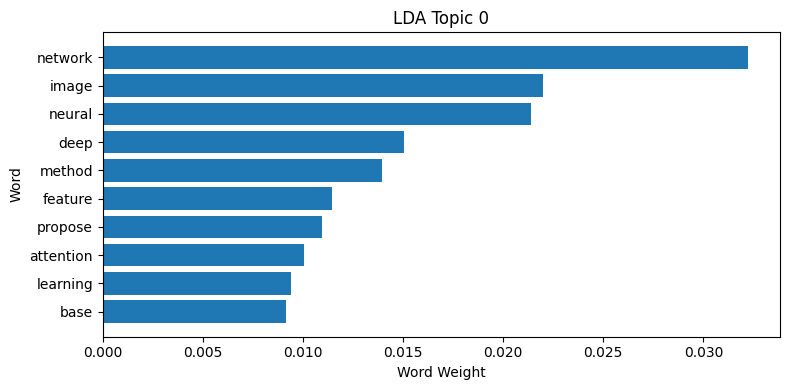

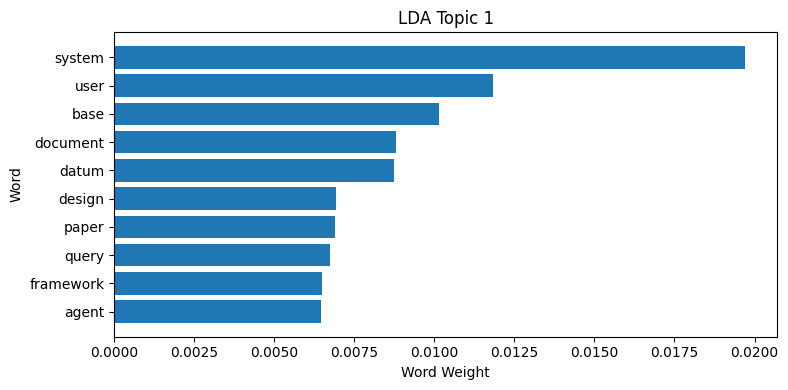

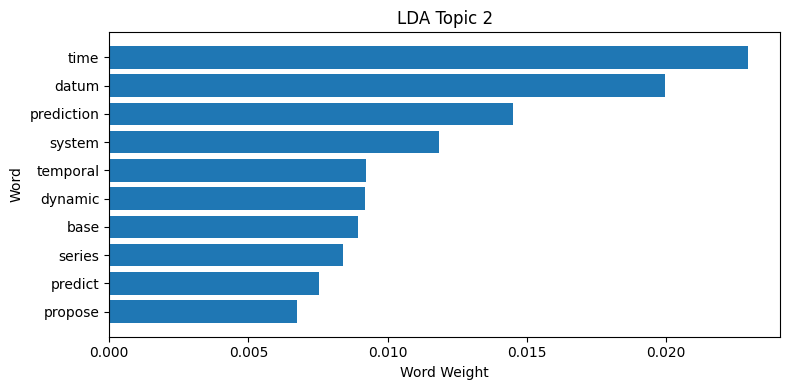

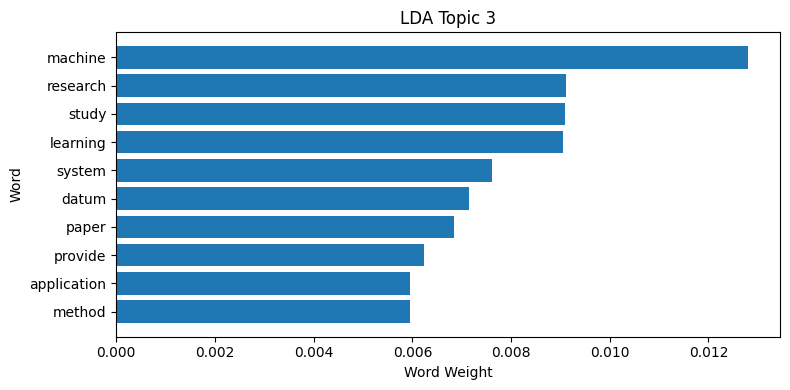

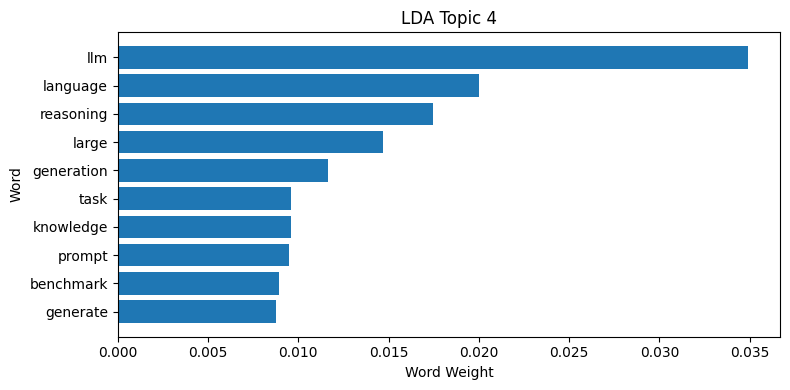

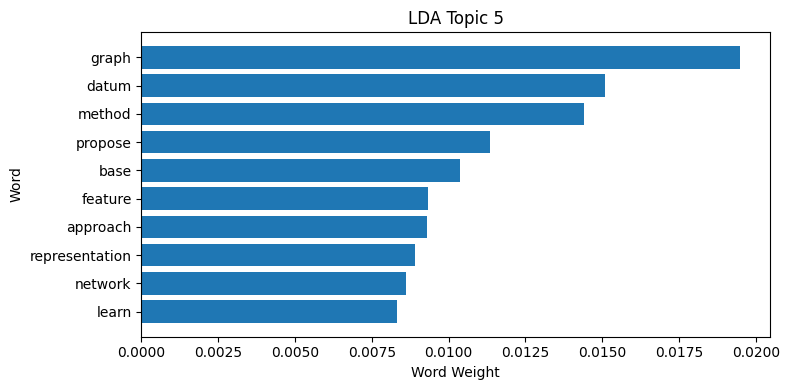

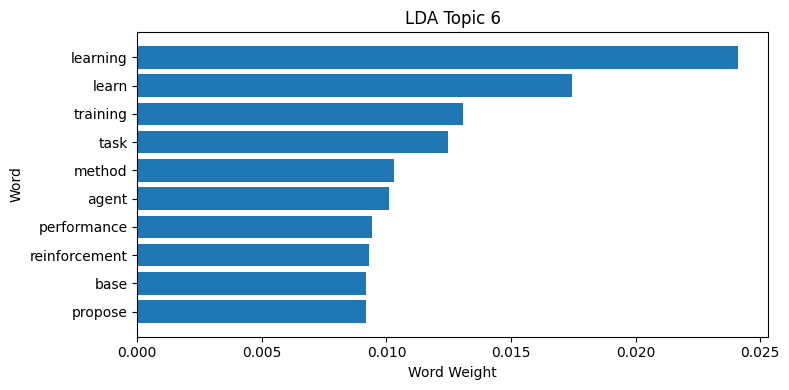

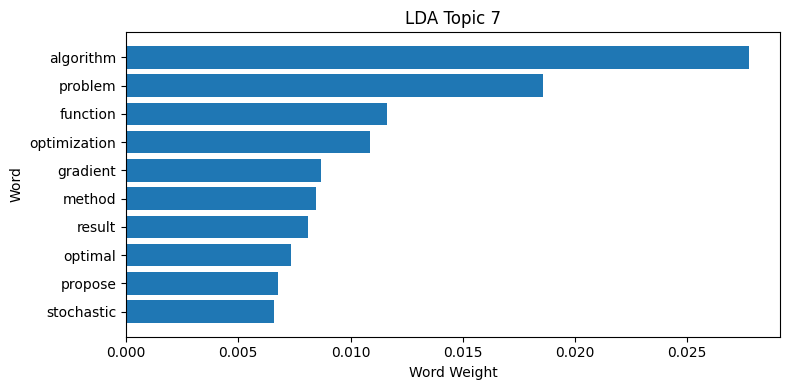

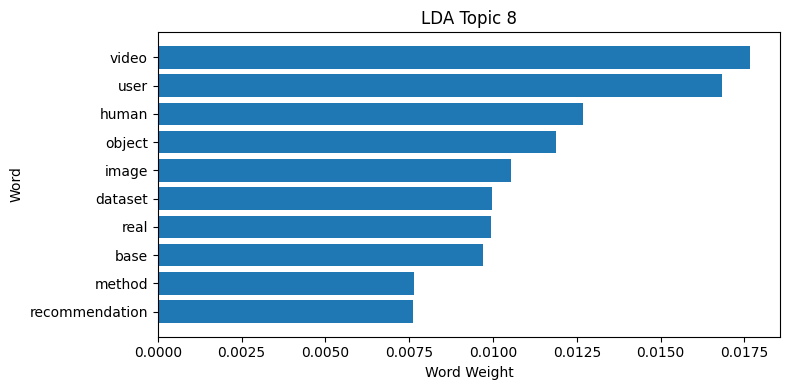

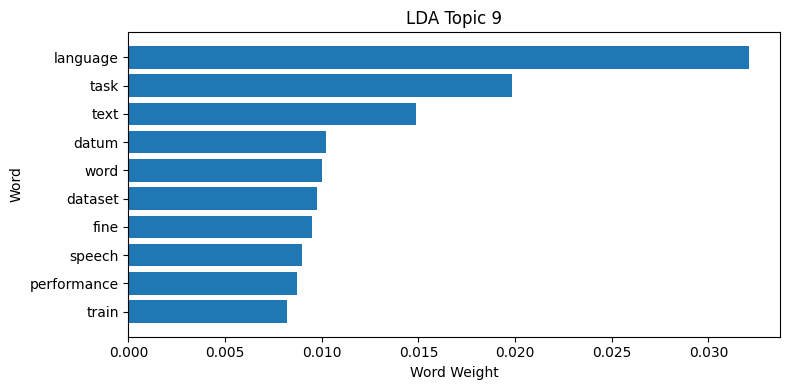

In [22]:
for topic_id in sorted(topics_df["topic_id"].unique()):
    subset = (
        topics_df[topics_df["topic_id"] == topic_id]
        .sort_values("weight", ascending=True)
    )

    plt.figure(figsize=(8, 4))
    plt.barh(subset["word"], subset["weight"])
    plt.title(f"LDA Topic {topic_id}")
    plt.xlabel("Word Weight")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

## Save topic modeling outputs

In [23]:
topics_path = save_table(topics_df, PATHS.data_processed / "notebook_lda_topics.csv")
summary_path = save_table(topic_summary, PATHS.data_processed / "notebook_lda_topic_summary.csv")

topics_json = {
    f"topic_{topic_id}": group[["word", "weight"]].to_dict(orient="records")
    for topic_id, group in topics_df.groupby("topic_id")
}

json_path = save_json(topics_json, PATHS.data_processed / "notebook_lda_topics.json")

print("Saved:", topics_path)
print("Saved:", summary_path)
print("Saved:", json_path)

Saved: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed\notebook_lda_topics.csv
Saved: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed\notebook_lda_topic_summary.csv
Saved: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed\notebook_lda_topics.json
